In [1]:
import zipfile
from google.colab import files
import os

print("Please upload your zipped image dataset folder (e.g., 'images.zip').")

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Assuming the uploaded file is a zip archive
  try:
    with zipfile.ZipFile(fn, 'r') as zip_ref:
      zip_ref.extractall(os.path.join(os.getcwd(), 'dataset')) # Extract to a 'dataset' folder
    print(f'Successfully extracted "{fn}" to the "dataset" folder.')
  except zipfile.BadZipFile:
    print(f'Error: "{fn}" is not a valid zip file. Please upload a zip archive.')
  except Exception as e:
    print(f'An unexpected error occurred: {e}')

# List the contents of the created 'dataset' folder to confirm
if os.path.exists('dataset'):
  print('\nContents of the \'dataset\' folder:')
  for root, dirs, files in os.walk('dataset'):
    level = root.replace('dataset', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
      print(f'{subindent}{f}')
else:
  print('\nNo \'dataset\' folder was created.')

Please upload your zipped image dataset folder (e.g., 'images.zip').


Saving Flower_Dataset.zip to Flower_Dataset.zip
User uploaded file "Flower_Dataset.zip" with length 215160703 bytes
Successfully extracted "Flower_Dataset.zip" to the "dataset" folder.

Contents of the 'dataset' folder:
dataset/
    Flower_Dataset/
        test/
            Image_611.jpg
            Image_223.jpg
            Image_354.jpg
            Image_763.jpg
            Image_692.jpg
            Image_8.jpg
            Image_53.jpg
            Image_618.jpg
            Image_502.jpg
            Image_590.jpg
            Image_664.jpg
            Image_22.jpg
            Image_659.jpg
            Image_480.jpg
            Image_248.jpg
            Image_408.jpg
            Image_350.jpg
            Image_613.jpg
            Image_429.jpg
            Image_145.jpg
            Image_81.jpg
            Image_67.jpg
            Image_639.jpg
            Image_2.jpg
            Image_454.jpg
            Image_789.jpg
            Image_146.jpg
            Image_784.jpg
            Image

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np
import os

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [8]:
# Define data directories
base_dir = 'dataset/Flower_Dataset'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Check if directories exist
if not os.path.exists(train_dir):
    print(f"Error: Training directory not found at {train_dir}")
if not os.path.exists(test_dir):
    print(f"Error: Test directory not found at {test_dir}")

# Image parameters
img_height, img_width = 224, 224
batch_size = 32

# Data generators with augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # Using 20% of training data for validation
)

# Data generator for testing (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Load validation data
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Load test data
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False # Keep data in order for evaluation
)

if test_generator.samples == 0:
    print(f"\nWarning: The test_generator found 0 images. This often happens if the test directory '{test_dir}' "
          f"does not contain subdirectories for each class. For 'class_mode=\"categorical\"', "
          f"images should be organized into class-specific subfolders within the test directory.")
    print("Please ensure your test data is structured correctly for evaluation (e.g., 'test/class1/img1.jpg', 'test/class2/img2.jpg').")


Found 2198 images belonging to 5 classes.
Found 548 images belonging to 5 classes.
Found 0 images belonging to 0 classes.

Please ensure your test data is structured correctly for evaluation (e.g., 'test/class1/img1.jpg', 'test/class2/img2.jpg').


In [5]:
num_classes = train_generator.num_classes

# Using MobileNetV2 as an efficient baseline if ShuffleNetV2 is not readily available
# You can replace this with a custom ShuffleNetV2 implementation if you have one.
base_model = tf.keras.applications.MobileNetV2(input_shape=(img_height, img_width, 3),
                                               include_top=False,
                                               weights='imagenet')

# Freeze the base model layers
base_model.trainable = False

# Add custom layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,574,853 (13.64 MB)

 Trainable params: 1,316,869 (5.02 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

epochs = 20 # You can adjust the number of epochs

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    verbose=1
)

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.7097 - loss: 0.7958 - val_accuracy: 0.8011 - val_loss: 0.5511
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.8530 - loss: 0.4283 - val_accuracy: 0.8175 - val_loss: 0.4721
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.8776 - loss: 0.3521 - val_accuracy: 0.8449 - val_loss: 0.4252
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.9004 - loss: 0.2965 - val_accuracy: 0.8631 - val_loss: 0.4068
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.9035 - loss: 0.2810 - val_accuracy: 0.8595 - val_loss: 0.3824
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.9217 - loss: 0.2454 - val_accuracy: 0.8577 - val_loss: 0.3846
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9313 - loss: 0.2119 - val_accuracy: 0.8376 - val_loss: 0.4531
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.9322 - loss: 0.2024 - val_accuracy: 0.8558 - v

In [9]:
print("\nEvaluating model on test data...")
if test_generator.samples == 0:
    print("Skipping evaluation and predictions: test_generator has 0 samples. Please check your test data setup (cell 4a735589).")
    loss = float('nan') # Assign NaN or a placeholder if evaluation is skipped
    accuracy = float('nan')
else:
    loss, accuracy = model.evaluate(test_generator, verbose=1)

    print(f'Test Loss: {loss:.4f}')
    print(f'Test Accuracy: {accuracy:.4f}')

    # Optional: Display some predictions
    print("\nDisplaying sample predictions:")
    predictions = model.predict(test_generator)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_generator.classes
    class_labels = list(test_generator.class_indices.keys())

    # Get a few sample images and their predictions
    num_samples_to_display = min(5, test_generator.samples)
    if num_samples_to_display > 0:
        print(f"Showing {num_samples_to_display} sample predictions (from test_generator):")
        for i in range(num_samples_to_display):
            # Accessing true_classes and predicted_classes which are aligned with test_generator samples
            true_label_idx = true_classes[i]
            pred_label_idx = predicted_classes[i]

            true_label_name = class_labels[true_label_idx] if true_label_idx < len(class_labels) else "Unknown"
            predicted_label_name = class_labels[pred_label_idx] if pred_label_idx < len(class_labels) else "Unknown"
            print(f"Sample {i+1}: True Label: {true_label_name}, Predicted Label: {predicted_label_name}")
    else:
        print("No test samples available to display predictions.")



Evaluating model on test data...
Skipping evaluation and predictions: test_generator has 0 samples. Please check your test data setup (cell 4a735589).


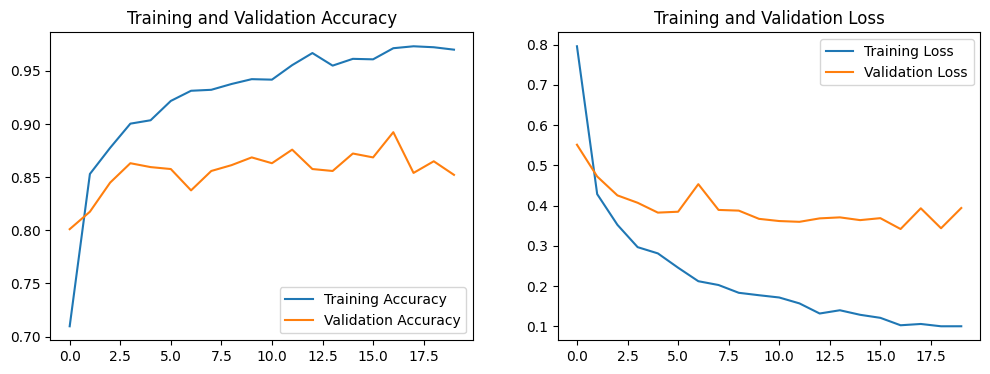

In [10]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()